# 2. Entendimiento de los datos

Esta fase responde tres preguntas antes de transformar nada: de dónde viene el dato, en qué unidad está y qué tan confiable es.
El cierre de la fase es una tabla de hallazgos con la decisión que cada uno obliga a tomar en la preparación.

## 2.1 Procedencia del dato

El PDF del reto no dice de dónde salen los datos. Buscando por la estructura de las columnas se llega a la Organización
Internacional del Café (ICO) y, en el camino, a un dataset público de Kaggle construido a partir de los Excel históricos de la ICO.

La hipótesis a verificar es que el archivo entregado es exactamente ese CSV público. La comparación se hace con
`assert_frame_equal`, no con `compare()`: `compare()` exige de entrada la misma forma, las mismas columnas y el mismo índice,
mientras que `assert_frame_equal` verifica esas condiciones y, si algo difiere, dice qué.

In [3]:
#%pip install pandas
#%pip install pyarrow

In [ ]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

data_dir = Path(
    r"C:\Users\david\Desktop\Personal\github_master\prueba-nttdata\data"
)

table = pq.read_table(data_dir / "coffee_db.parquet")
parquet_coffee_db = table.to_pandas()

parquet_coffee_db_original = pd.read_csv(
    data_dir / "coffee_db_original.csv"
)

In [25]:
print(f'Estructura: {parquet_coffee_db.shape}')
print(f'Tamaño: {parquet_coffee_db.shape}')

parquet_coffee_db.info()

Estructura: (55, 33)
Tamaño: (55, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Country                     55 non-null     object
 1   Coffee type                 55 non-null     object
 2   1990/91                     55 non-null     int64 
 3   1991/92                     55 non-null     int64 
 4   1992/93                     55 non-null     int64 
 5   1993/94                     55 non-null     int64 
 6   1994/95                     55 non-null     int64 
 7   1995/96                     55 non-null     int64 
 8   1996/97                     55 non-null     int64 
 9   1997/98                     55 non-null     int64 
 10  1998/99                     55 non-null     int64 
 11  1999/00                     55 non-null     int64 
 12  2000/01                     55 non-null     int64 
 13  2001/02       

In [26]:
print(f'Estructura: {parquet_coffee_db_original.shape}')
print(f'Tamaño: {parquet_coffee_db_original.shape}')

parquet_coffee_db_original.info()

Estructura: (55, 33)
Tamaño: (55, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Country                     55 non-null     object
 1   Coffee type                 55 non-null     object
 2   1990/91                     55 non-null     int64 
 3   1991/92                     55 non-null     int64 
 4   1992/93                     55 non-null     int64 
 5   1993/94                     55 non-null     int64 
 6   1994/95                     55 non-null     int64 
 7   1995/96                     55 non-null     int64 
 8   1996/97                     55 non-null     int64 
 9   1997/98                     55 non-null     int64 
 10  1998/99                     55 non-null     int64 
 11  1999/00                     55 non-null     int64 
 12  2000/01                     55 non-null     int64 
 13  2001/02       

En este punto, se genera una pregunta evidente: ¿Es este el mismo dataset? Ya que vemos el mismo nùmero de datos, aparentemente el mismo nombre de columnas, y observando superficialmente, los mismos datos

Para averiguarlo, es posible comparar las diferencias

In [27]:
print("misma forma:", parquet_coffee_db_original.shape == parquet_coffee_db.shape)
print("mismas columnas y orden:", list(parquet_coffee_db_original.columns) == list(parquet_coffee_db.columns))
print("mismo orden de países:", parquet_coffee_db_original["Country"].tolist() == parquet_coffee_db["Country"].tolist())

year = [c for c in parquet_coffee_db.columns if "/" in c]

from pandas.testing import assert_frame_equal
assert_frame_equal(parquet_coffee_db_original, parquet_coffee_db, check_dtype=False)

print(f"\nIdénticos: {parquet_coffee_db.shape[0]} filas x {len(year)} años, 0 diferencias en {parquet_coffee_db[year].size} valores")

misma forma: True
mismas columnas y orden: True
mismo orden de países: True

Idénticos: 55 filas x 30 años, 0 diferencias en 1650 valores


Así, observamos que, efectivamente, el archivo disponible por High Garden coffee es un archivo de consumo por país de café. Esto es importante ya que podemos ir al origen, y entender la información desde la fuente.

En este caso en concreto, y para el desarrollo de la prueba, hay un cambio fundamental, y es que las unidades no es en tazas, sino en **kilogramos** (dada la información disponible en la fuente original).

Esto pemrite hacer una comparativa no solo desde el consumo, sino inclusive desde la producción de cada país, para identificar oportunidades más claras asociadas a la oferta y la demnanda, sin necesidad de asumir la cantidad de gramos que tiene una taza, llevarlo a kilogramos, e incrementar el error,

## 2.2 Estructura e integridad

Las verificaciones se escriben como `assert` y no como `print`: documentan la expectativa y rompen el notebook si el dato
cambia, en vez de obligar a leer una salida. Se revisa el número de años, la continuidad de la serie, la unicidad de los países,
el tipo de dato y la coherencia interna de la columna acumulada `Total_domestic_consumption`.

In [28]:
assert parquet_coffee_db["Country"].is_unique
assert parquet_coffee_db[year].dtypes.eq("int64").all()

suma_anios = parquet_coffee_db[year].sum(axis=1)
coherentes = (suma_anios == parquet_coffee_db["Total_domestic_consumption"]).sum()

print(f"países: {parquet_coffee_db['Country'].nunique()} | años: {len(year)} | columnas: {parquet_coffee_db.shape[1]}")
print(f"tipos de café: {parquet_coffee_db['Coffee type'].unique().tolist()}")
print(f"Total_domestic_consumption = suma de los 30 años en {coherentes} de {len(parquet_coffee_db)} países")

países: 55 | años: 30 | columnas: 33
tipos de café: ['Robusta/Arabica', 'Arabica', 'Arabica/Robusta', 'Robusta']
Total_domestic_consumption = suma de los 30 años en 55 de 55 países


## 2.3. Datos faltantes: el cero es el faltante

`isna().sum()` devuelve cero en todas las columnas, y eso es engañoso: la fuente codifica el dato no reportado como **0**.
Un país productor con consumo interno exactamente cero no es creíble.

Lo que importa no es cuántos ceros hay, sino su forma, porque cada patrón obliga a una decisión distinta:
ceros al inicio (serie que arranca tarde), ceros al final (país que deja de reportar) y serie completa en cero (país sin dato).

In [29]:
import numpy as np

ceros = parquet_coffee_db[year].eq(0)

def patron(fila):
    idx = np.flatnonzero(fila.values)
    if idx.size == 0:
        return "sin ceros"
    if idx.size == len(year):
        return "serie completa en cero"
    if (idx == np.arange(idx.size)).all():
        return "ceros al inicio"
    if (idx == np.arange(len(year) - idx.size, len(year))).all():
        return "ceros al final"
    return "ceros intercalados"

diag = pd.DataFrame({
    "patron": ceros.apply(patron, axis=1).values,
    "anios_en_cero": ceros.sum(axis=1).values,
    "consumo_2019_20_sacos": parquet_coffee_db["2019/20"].values / 60,
}, index=parquet_coffee_db["Country"])

print(f"nulos declarados: {int(parquet_coffee_db[year].isna().sum().sum())} | ceros: {int(ceros.values.sum())} en {int(ceros.any(axis=1).sum())} países\n")
print(diag["patron"].value_counts().to_string())
diag[diag["patron"] != "sin ceros"].sort_values("anios_en_cero", ascending=False).round(0)

nulos declarados: 0 | ceros: 124 en 7 países

patron
sin ceros                 48
ceros al inicio            4
serie completa en cero     2
ceros al final             1


,patron,anios_en_cero,consumo_2019_20_sacos
Country,,,
Equatorial Guinea,serie completa en cero,30,0.0
Nepal,serie completa en cero,30,0.0
Timor-Leste,ceros al inicio,20,490.0
Yemen,ceros al inicio,13,64000.0
Lao People's Democratic Republic,ceros al inicio,12,157000.0
Zambia,ceros al final,11,0.0
Guyana,ceros al inicio,8,9000.0


Los 124 ceros se concentran en 7 países; los otros 48 tienen serie completa.

| Patrón | Países | Lectura | Decisión |
|---|---|---|---|
| Ceros al inicio | Timor-Leste, Yemen, Laos, Guyana | La serie arranca tarde | Cero → faltante; serie más corta para modelar |
| Serie completa en cero | Nepal, Guinea Ecuatorial | Nunca hubo dato | Excluir del análisis por país |
| Ceros al final | Zambia | Dejó de reportar | Cero → faltante; no extrapolar el último tramo |

En los tres casos el cero se convierte en faltante, nunca en un consumo real de cero: tratado como valor, inflaría los
promedios a la baja y produciría falsos déficits al cruzar con producción.

## 2.4 Distribución: pocos países concentran el volumen

El consumo por país tiene una cola muy larga. La asimetría lo cuantifica y decide dos cosas del resto del análisis:
usar escala logarítmica en los gráficos y comparar países con tasas y ratios en lugar de volúmenes absolutos.

asimetría en nivel: 6.09
participación del mayor consumidor: 44%
participación de los 10 mayores: 90%

count    52.00
mean      0.96
std       3.16
min       0.00
25%       0.01
50%       0.09
75%       0.36
max      22.00


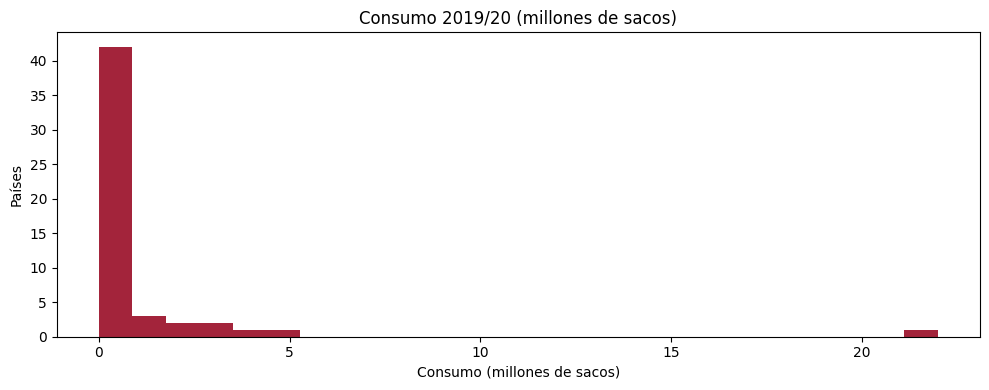

In [30]:
from matplotlib import pyplot as plt

ultimo = (parquet_coffee_db.set_index("Country")["2019/20"] / 60).replace(0, np.nan).dropna()

print(f"asimetría en nivel: {ultimo.skew():.2f}")
print(f"participación del mayor consumidor: {ultimo.max() / ultimo.sum():.0%}")
print(f"participación de los 10 mayores: {ultimo.nlargest(10).sum() / ultimo.sum():.0%}\n")
print((ultimo / 1e6).describe().round(2).to_string())

fig, axes = plt.subplots(1, 1, figsize=(10, 4))
axes.hist(ultimo / 1e6, bins=25, color="#A3243B")
axes.set_title("Consumo 2019/20 (millones de sacos)")
axes.set_xlabel("Consumo (millones de sacos)")
axes.set_ylabel("Países")
plt.tight_layout()
plt.show()

## 2.5 Comportamiento temporal

Tres lecturas sobre el eje del tiempo, cada una con una consecuencia distinta:

1. **Tendencia agregada:** el consumo interno de los países productores crece de forma sostenida. Es el supuesto sobre el que
   se apoya la pregunta de negocio (¿hay productores que se están volviendo mercados?).
2. **Crecimiento por país:** el crecimiento anual compuesto de la última década separa a los mercados que se mueven de los estancados.
3. **Forma de la serie:** cuántas veces cambia realmente el valor de cada país.

consumo total: 19.5 → 50.0 millones de sacos (CAGR 3.30%)


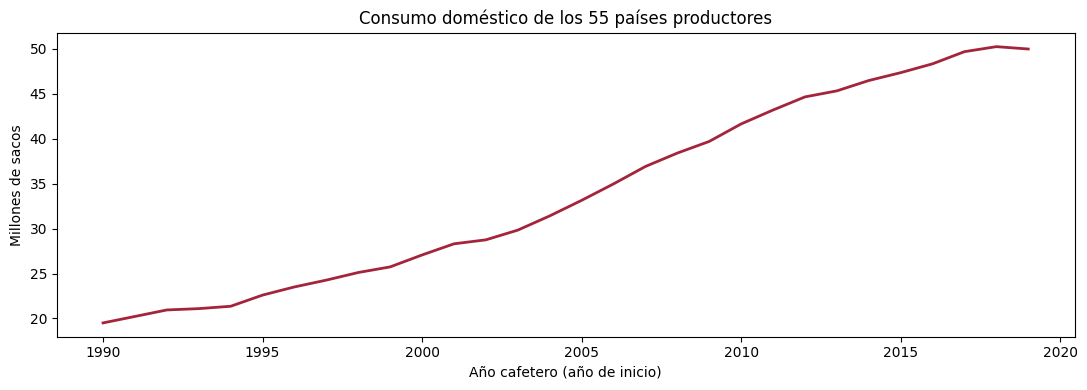

In [31]:
largo = (parquet_coffee_db.melt(id_vars=["Country", "Coffee type"], value_vars=year,
                      var_name="crop_year", value_name="consumo_kg")
         .assign(anio=lambda d: d["crop_year"].str[:4].astype(int),
                 consumo_sacos=lambda d: d["consumo_kg"].div(60).replace(0, np.nan)))

agregado = largo.groupby("anio")["consumo_sacos"].sum() / 1e6
cagr = lambda s: (s.iloc[-1] / s.iloc[0]) ** (1 / (len(s) - 1)) - 1

print(f"consumo total: {agregado.iloc[0]:.1f} → {agregado.iloc[-1]:.1f} millones de sacos "
      f"(CAGR {cagr(agregado):.2%})")

ax = agregado.plot(figsize=(11, 4), linewidth=2, color="#A3243B")
ax.set_title("Consumo doméstico de los 55 países productores")
ax.set_xlabel("Año cafetero (año de inicio)")
ax.set_ylabel("Millones de sacos")
plt.tight_layout()
plt.show()

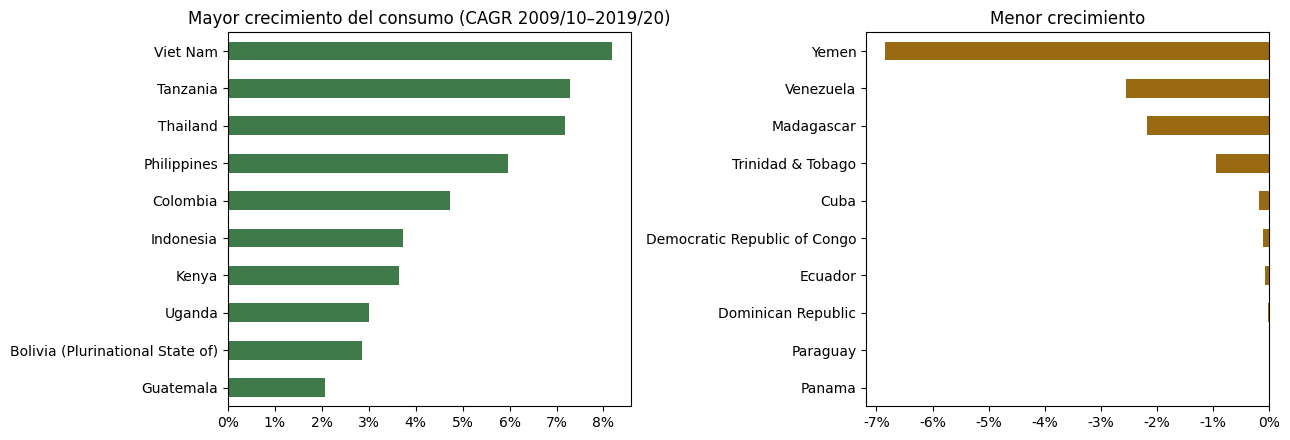

In [32]:
pivot = largo.pivot(index="Country", columns="crop_year", values="consumo_sacos")
base, fin = pivot["2009/10"], pivot["2019/20"]
crecimiento = (((fin / base) ** (1 / 10) - 1)
               .where(base >= 10_000)
               .replace([np.inf, -np.inf], np.nan)
               .dropna()
               .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
crecimiento.head(10)[::-1].plot.barh(ax=axes[0], color="#3F7A4A")
axes[0].set_title("Mayor crecimiento del consumo (CAGR 2009/10–2019/20)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
crecimiento.tail(10).plot.barh(ax=axes[1], color="#9A6A12")
axes[1].set_title("Menor crecimiento")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for a in axes:
    a.set_ylabel("")
plt.tight_layout()
plt.show()